In [1]:
%load_ext autoreload
%autoreload 2

In [29]:
import pandas as pd
import numpy as np
import re
import pycountry
import seaborn as sns
import country_converter as coco
import matplotlib.pyplot as plt
from cleaning_utils import *

sd_df=pd.read_excel("https://www.sharkattackfile.net/spreadsheets/GSAF5.xls")

sd_df=sd_df.drop(columns=['Source','pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'])

In [ ]:
# data cleaning

In [30]:
def clean_all(df):
    df2 = df.copy()
    df2 = clean_col_date(df2)
    df2 = clean_col_names(df2)
    df2 = clean_df(df2)
    df2 = clean_col_3_type(df2)
    df2 = clean_col_activity(df2)
    df2 = clean_col_4_country(df2)
    df2 = clean_col_sex(df2)
    df2 = clean_col_age(df2)
    return df2

def filter_for_recent_attacks(df):
    df2 = df.copy()
    df2.loc[df2['year']>=1990]
    return df2

df3 = clean_all(sd_df)

In [ ]:
# EDA

In [44]:
# Explore the overall distribution of shark attack incidents

# Top 10 activities associated with shark attacks
display(df3.activity.value_counts().head(10))
print()
# Top 10 countries with the highest number of reported shark attacks
display(df3[df3['country'] != 'other']['country'].value_counts().head(10))
print()
# Number of shark attacks involving males and females
display(df3[df3['sex'].isin(['M', 'F'])]['sex'].value_counts())

activity
swimming           1607
fishing            1267
surfing            1156
diving              566
wading              178
boarding            120
standing            115
body boarding        70
boogie boarding      60
body surfing         55
Name: count, dtype: int64

country
UNITED STATES       2580
AUSTRALIA           1529
SOUTH AFRICA         599
NEW ZEALAND          146
BAHAMAS              142
PAPUA NEW GUINEA     136
BRAZIL               123
MEXICO               107
ITALY                 72
FIJI                  70
Name: count, dtype: int64

sex
M    5693
F     813
Name: count, dtype: int64

In [38]:
# Analyze age distribution of shark attack victims by sex

# Remove rows with missing age or sex values
df4 = df3.dropna(subset=['age', 'sex'])
# Keep only valid sex categories (M and F)
df4 = df4[df4['sex'].isin(['M', 'F'])]
# Remove rows where age is unknown
df4 = df4[df4['age']!='unknown']
# Calculate age statistics grouped by sex, explore the age profile of male and female shark attack victims
# count: number of victims
# mean: average victim age
# std: age variability / spread of ages, a larger standard deviation in age suggests that shark attacks affect a wider range of ages
display(df4.groupby('sex')['age'].agg(['count', 'mean', 'std']))

,count,mean,std
sex,,,
F,311,27.363344,16.975309
M,1645,28.37386,14.277726


In [41]:
# Analyze the distribution of shark attack activities by sex

# Remove rows with missing activity or sex values
df5 = df3.dropna(subset=['activity', 'sex'])
# Keep only valid sex categories (M and F)
df5 = df5[df5['sex'].isin(['M', 'F'])]
# Select the top 5 most common activities
top_activity = list(df5.activity.value_counts().head(5).index)
# Filter dataset to include only the top 5 activities
df5 = df5[df5['activity'].isin(top_activity)]
# Count shark attack incidents by sex and activity
df5_grouped = df5.groupby(["sex","activity"]).agg({"activity": 'count'})
display(df5_grouped)
# Calculate percentage distribution of activities within each sex group
df5_grouped.groupby(["sex"]).agg({"activity": 'count'})
display(
    df5_grouped.groupby(level=0, group_keys=False)
    .apply(
        lambda x: round(
            100 * x / x.sum().iloc[0],
            2
        )
    )
)

activity
sex activity          
F   diving          38
    fishing         25
    surfing         75
    swimming       329
    wading          70
M   diving         507
    fishing       1070
    surfing       1055
    swimming      1240
    wading         105

activity
sex activity          
F   diving        7.08
    fishing       4.66
    surfing      13.97
    swimming     61.27
    wading       13.04
M   diving       12.75
    fishing      26.90
    surfing      26.53
    swimming     31.18
    wading        2.64

In [43]:
# Analyze shark attack activity distribution across countries

df6 = df3.dropna(subset=['activity', 'country'])
top_country = list(df5[df5['country']!='other'].country.value_counts().head(10).index)
df6 = df6[df6['country'].isin(top_country)]
top_activity = list(df6.activity.value_counts().head(5).index)
df6 = df6[df6['activity'].isin(top_activity)]
# Count shark attack incidents by country and activity
df6_grouped = df6.groupby(["country","activity"]).agg({"activity": 'count'})
display(df6_grouped)
# Calculate percentage distribution of activities within each country
df6_grouped.groupby(["country"]).agg({"activity": 'count'})
display(df6_grouped.groupby(level=0, group_keys=False).apply(lambda x: round(100 * x / float(x.sum().iloc[0]), 2)))

activity
country          activity          
AUSTRALIA        diving         161
                 fishing        289
                 surfing        257
                 swimming       351
                 wading          18
BAHAMAS          diving          22
                 fishing         55
                 surfing          2
                 swimming        25
                 wading           1
BRAZIL           diving           2
                 fishing          7
                 surfing         39
                 swimming        43
                 wading           2
EGYPT            diving          12
                 fishing          3
                 swimming        26
ITALY            diving           9
                 fishing         26
                 swimming        14
MEXICO           diving          18
                 fishing         14
                 surfing          7
                 swimming        41
                 wading           6
NEW ZEALAND      diving           8
                 fishing         37
                 surfing         17
                 swimming        42
                 wading           2
PAPUA NEW GUINEA diving          10
                 fishing         54
                 swimming        22
                 wading           2
SOUTH AFRICA     diving          31
                 fishing        135
                 surfing        100
                 swimming       115
                 wading           9
UNITED STATES    diving         137
                 fishing        338
                 surfing        670
                 swimming       521
                 wading         124

activity
country          activity          
AUSTRALIA        diving       14.96
                 fishing      26.86
                 surfing      23.88
                 swimming     32.62
                 wading        1.67
BAHAMAS          diving       20.95
                 fishing      52.38
                 surfing       1.90
                 swimming     23.81
                 wading        0.95
BRAZIL           diving        2.15
                 fishing       7.53
                 surfing      41.94
                 swimming     46.24
                 wading        2.15
EGYPT            diving       29.27
                 fishing       7.32
                 swimming     63.41
ITALY            diving       18.37
                 fishing      53.06
                 swimming     28.57
MEXICO           diving       20.93
                 fishing      16.28
                 surfing       8.14
                 swimming     47.67
                 wading        6.98
NEW ZEALAND      diving        7.55
                 fishing      34.91
                 surfing      16.04
                 swimming     39.62
                 wading        1.89
PAPUA NEW GUINEA diving       11.36
                 fishing      61.36
                 swimming     25.00
                 wading        2.27
SOUTH AFRICA     diving        7.95
                 fishing      34.62
                 surfing      25.64
                 swimming     29.49
                 wading        2.31
UNITED STATES    diving        7.65
                 fishing      18.88
                 surfing      37.43
                 swimming     29.11
                 wading        6.93

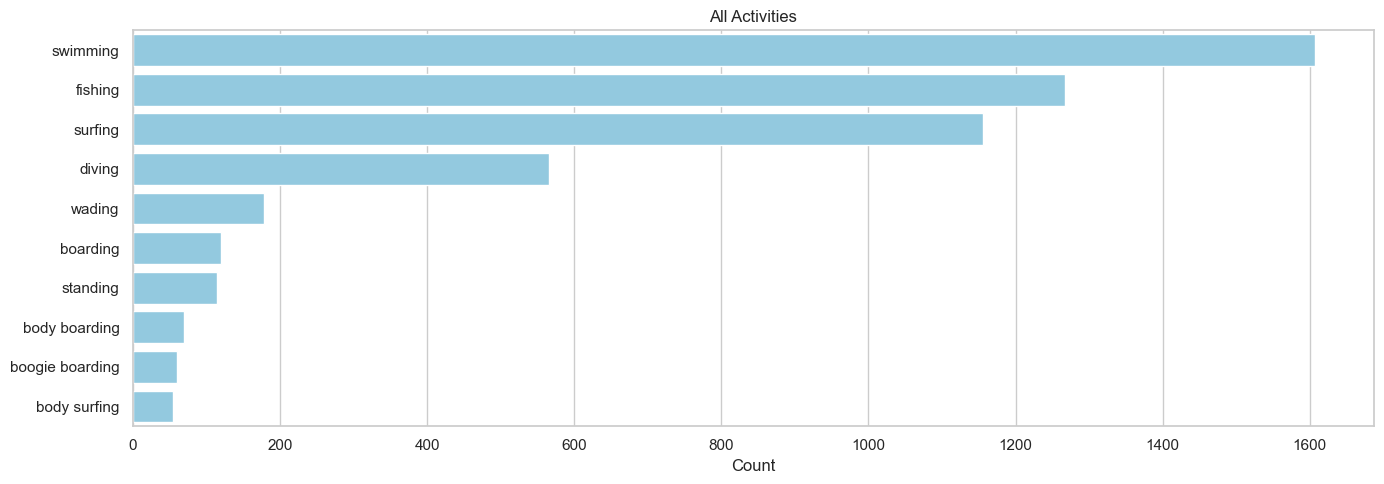

In [45]:
# Visualize the distribution of shark attack activities

sns.set_theme(style="whitegrid")

# -----------------------------
# Plot 1: Swimming vs Boarding
# -----------------------------

plot_data = (
    df3[df3['activity'].isin(['swimming', 'boarding'])]
    ['activity']
    .value_counts()
    .reset_index()
)

plot_data.columns = ['activity', 'count']

# -----------------------------
# Plot 2: All activities
# -----------------------------

all_activities = (
    df3['activity']
    .value_counts()
    .head(10)
    .reset_index()
)

all_activities.columns = ['activity', 'count']

# -----------------------------
# Create subplots
# -----------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=1, #2,
    figsize=(14, 5)
)

sns.barplot(
    data=all_activities,
    x='count',
    y='activity',
    color='skyblue',
    ax=axes
)

axes.set_title('All Activities')
axes.set_xlabel('Count')
axes.set_ylabel('')

plt.tight_layout()
plt.show()

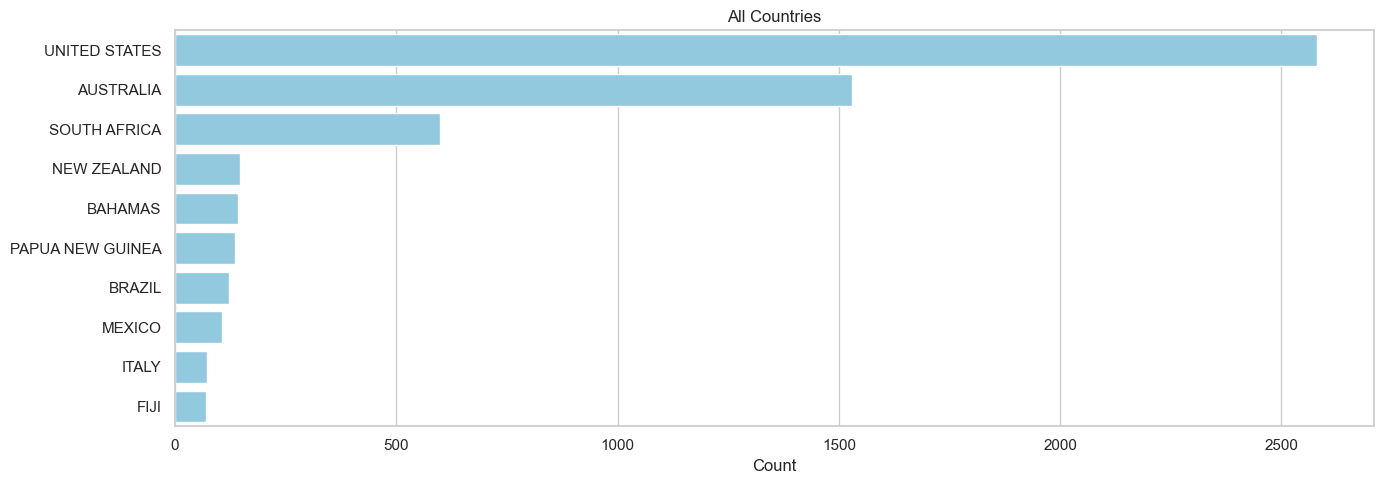

In [46]:
# Visualize the countries with the highest number of shark attack reports

sns.set_theme(style="whitegrid")

all_countries = (
    df3[df3['country'] != 'other']['country']
    .value_counts()
    .head(10)
    .reset_index()
)

all_countries.columns = ['country', 'count']

fig, axes = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(14, 5)
)

sns.barplot(
    data=all_countries,
    x='count',
    y='country',
    color='skyblue',
    ax=axes
)

axes.set_title('All Countries')
axes.set_xlabel('Count')
axes.set_ylabel('')

plt.tight_layout()
plt.show()

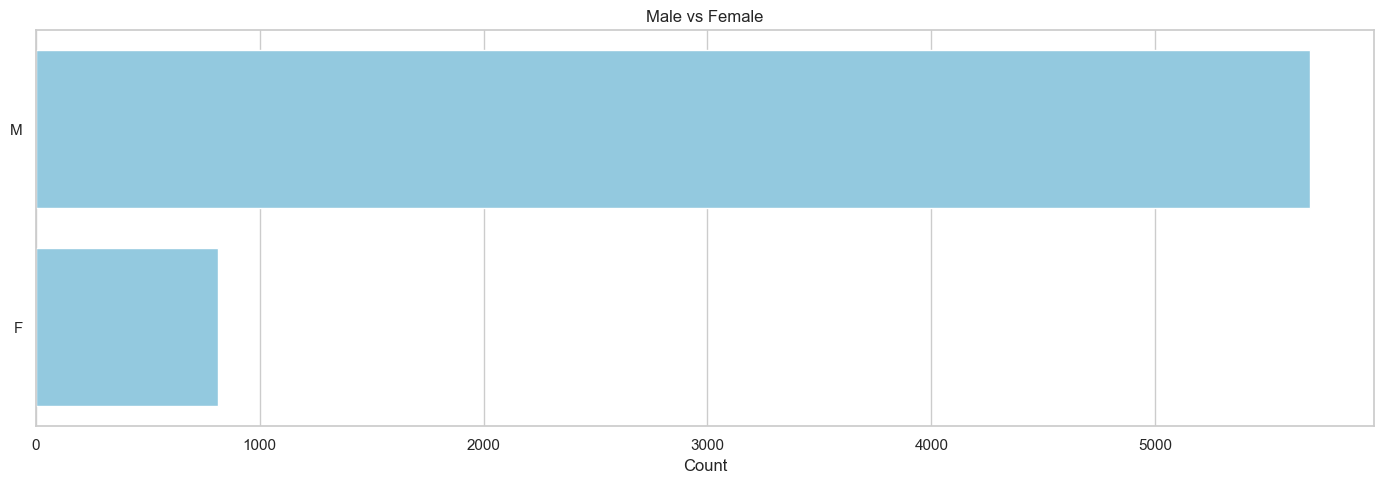

In [48]:
# Visualize shark attack victim distribution by sex

sns.set_theme(style="whitegrid")

plot_data = (
    df3[df3['sex'].isin(['M', 'F'])]
    ['sex']
    .value_counts()
    .reset_index()
)

plot_data.columns = ['sex', 'count']

fig, axes = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(14, 5)
)

sns.barplot(
    data=plot_data,
    x='count',
    y='sex',
    color='skyblue',
    ax=axes
)

axes.set_title('Male vs Female')
axes.set_xlabel('Count')
axes.set_ylabel('')

plt.tight_layout()
plt.show()

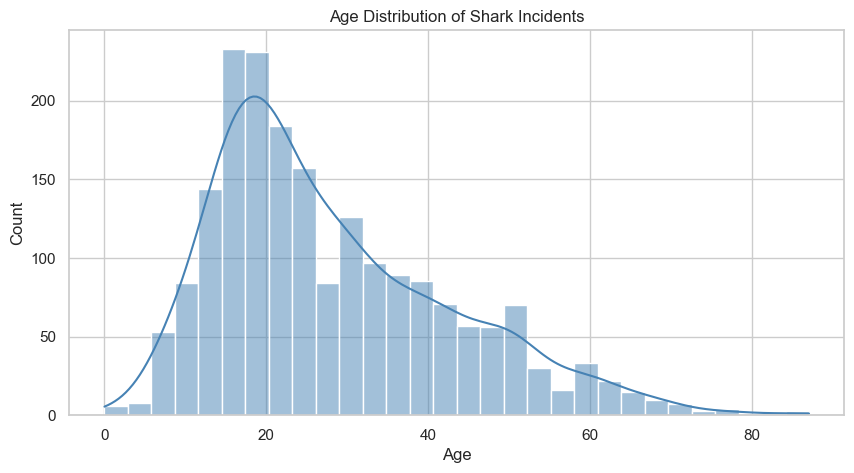

In [50]:
# Visualize the age distribution of shark attack victims

sns.set_theme(style="whitegrid")

df_plot = df3.copy()

# Remove unknown age values
df_plot = df_plot[df_plot['age'] != 'unknown']

# Convert age column to numeric
df_plot['age'] = pd.to_numeric(
    df_plot['age'],
    errors='coerce'
)

# Remove remaining invalid numeric values
df_plot = df_plot.dropna(subset=['age'])

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_plot,
    x='age',
    bins=30,
    kde=True,
    color='steelblue'
)

plt.title("Age Distribution of Shark Incidents")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

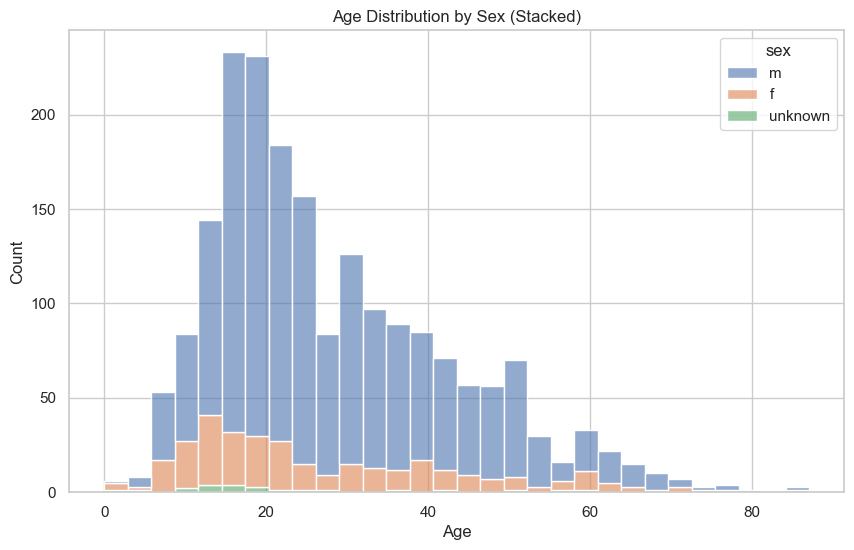

In [53]:
# Compare age distributions of shark attack victims by sex

df_plot = df3[['age', 'sex']].copy()

# clean age
df_plot['age'] = pd.to_numeric(df_plot['age'],
    errors='coerce')

# clean sex
df_plot['sex'] = df_plot['sex'].str.lower().str.strip()

# drop missing
df_plot = df_plot.dropna(subset=['age', 'sex'])


plt.figure(figsize=(10, 6))

# stacked histogram
sns.histplot(
    data=df_plot,
    x='age',
    hue='sex',
    multiple='stack',
    bins=30,
    alpha=0.6
)

plt.title("Age Distribution by Sex (Stacked)")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

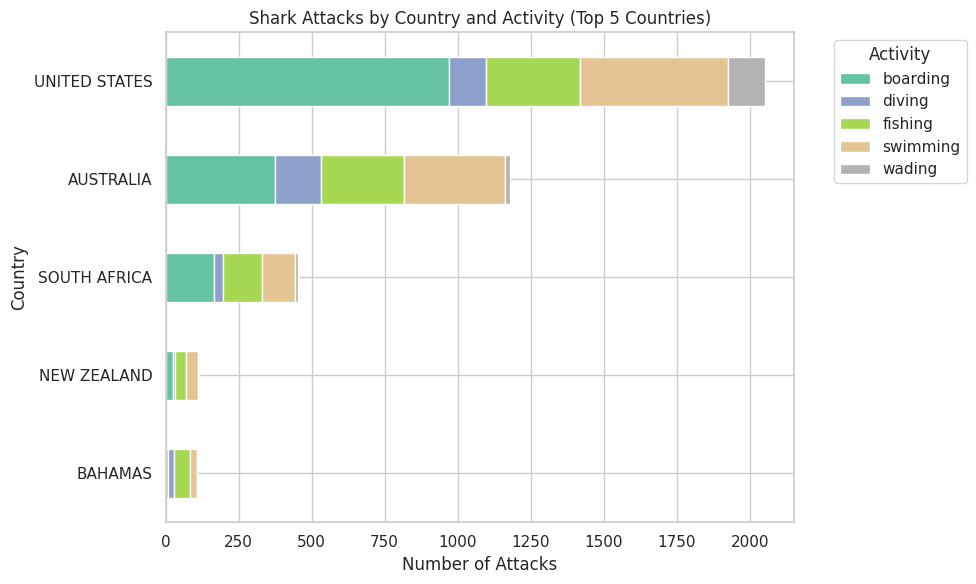

In [ ]:
# Compare shark attack activities across top reporting countries

df_plot = df3[['country', 'activity']].copy()

df_plot = df_plot.dropna(subset=['country', 'activity'])

df_plot = df_plot[df_plot['country'] != 'other']
top_countries = df_plot['country'].value_counts().head(5).index
top_activities = df_plot['activity'].value_counts().head(5).index

df_plot = df_plot[
    df_plot['country'].isin(top_countries) &
    df_plot['activity'].isin(top_activities)
]
attack_matrix = pd.crosstab(
    df_plot['country'],
    df_plot['activity']
)

attack_matrix = attack_matrix.loc[
    attack_matrix.sum(axis=1).sort_values().index
]

attack_matrix.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 6),
    colormap='Set2' #'tab20'
)

plt.title("Shark Attacks by Country and Activity (Top 5 Countries)")
plt.xlabel("Number of Attacks")
plt.ylabel("Country")

plt.legend(title="Activity", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()

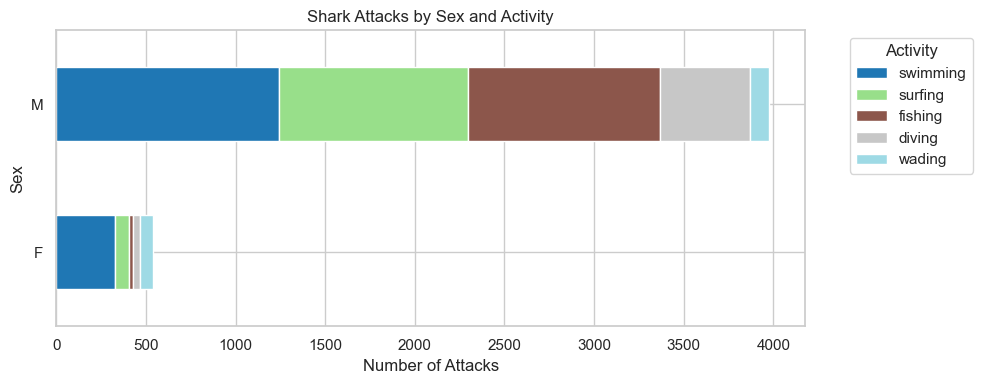

In [54]:
# Compare shark attack activities between male and female victims

df_plot = df3[['sex', 'activity']].copy()

df_plot = df_plot.dropna(subset=['sex', 'activity'])



# keep only Male/Female
df_plot = df_plot[df_plot['sex'].isin(['M', 'F'])]

# ----------------------------
# Keep top 5 activities
# ----------------------------

top_activities = (
    df_plot['activity']
    .value_counts()
    .head(5)
    .index
)

df_plot = df_plot[df_plot['activity'].isin(top_activities)]

# ----------------------------
# Build matrix
# ----------------------------

sex_activity = pd.crosstab(
    df_plot['sex'],
    df_plot['activity']
)

# ----------------------------
# Order activities by frequency
# ----------------------------

sex_activity = sex_activity[
    sex_activity.sum(axis=0)
    .sort_values(ascending=False)
    .index
]

# ----------------------------
# Plot
# ----------------------------

sex_activity.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 4),
    colormap='tab20'
)

plt.title("Shark Attacks by Sex and Activity")
plt.xlabel("Number of Attacks")
plt.ylabel("Sex")

plt.legend(
    title="Activity",
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()
plt.show()

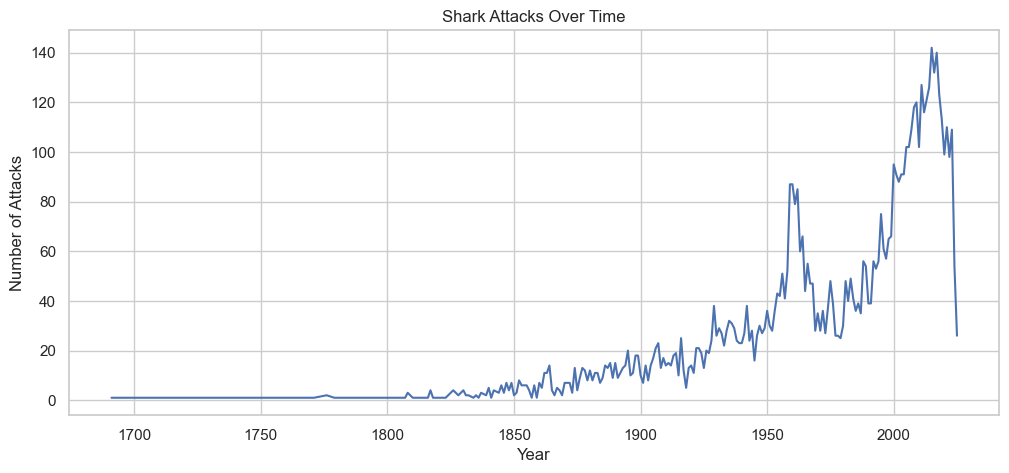

In [55]:
# Analyze shark attack trends over time

# Create a copy for time analysis
df_time = df3.copy()

# Remove missing dates
df_time = df_time.dropna(subset=['date'])

# Extract year from date
df_time['year'] = df_time['date'].dt.year

# Count shark attacks per year
attacks_per_year = (
    df_time['year']
    .value_counts()
    .sort_index()
)

# Create line plot
plt.figure(figsize=(12, 5))

sns.lineplot(
    x=attacks_per_year.index,
    y=attacks_per_year.values
)

# Customize plot labels and title
plt.title("Shark Attacks Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")

# Display figure
plt.show()

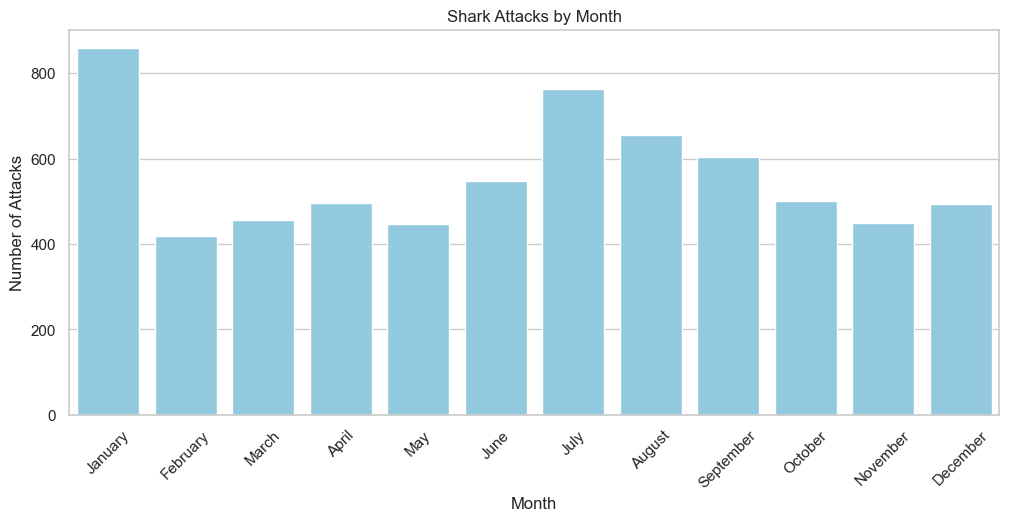

In [56]:
# Analyze seasonal patterns of shark attacks

# Extract month
df_time['month'] = df_time['date'].dt.month_name()

# Define month order
month_order = [
    'January', 'February', 'March',
    'April', 'May', 'June',
    'July', 'August', 'September',
    'October', 'November', 'December'
]

# Count attacks by month
monthly_attacks = (
    df_time['month']
    .value_counts()
    .reindex(month_order)
)

# Create bar plot
plt.figure(figsize=(12, 5))

sns.barplot(
    x=monthly_attacks.index,
    y=monthly_attacks.values,
    color='skyblue'
)

# Customize labels and title
plt.title("Shark Attacks by Month")
plt.xlabel("Month")
plt.ylabel("Number of Attacks")

plt.xticks(rotation=45)

# Display figure
plt.show()

In [62]:
monthly_attacks = (
    df3.dropna(subset=['date'])
    .assign(month=lambda x: x['date'].dt.month_name())
    ['month']
    .value_counts()
)

monthly_attacks

month
January      859
July         762
August       656
September    604
June         548
October      500
April        497
December     494
March        455
November     450
May          447
February     419
Name: count, dtype: int64

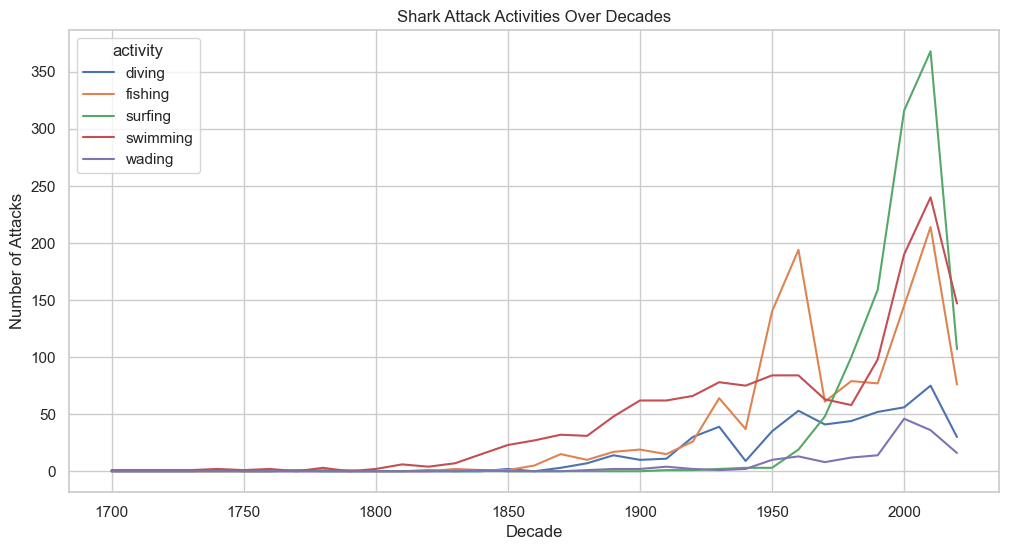

In [57]:
# Analyze changes in shark attack activities over time

# Create decade column
df_time['decade'] = (
    df_time['year'] // 10
) * 10

# Keep top activities
top_activities = (
    df_time['activity']
    .value_counts()
    .head(5)
    .index
)

df_activity = df_time[
    df_time['activity'].isin(top_activities)
]

# Create activity trend table
activity_trend = pd.crosstab(
    df_activity['decade'],
    df_activity['activity']
)

# Plot trends
activity_trend.plot(
    figsize=(12, 6)
)

# Customize labels and title
plt.title("Shark Attack Activities Over Decades")
plt.xlabel("Decade")
plt.ylabel("Number of Attacks")

# Display figure
plt.show()

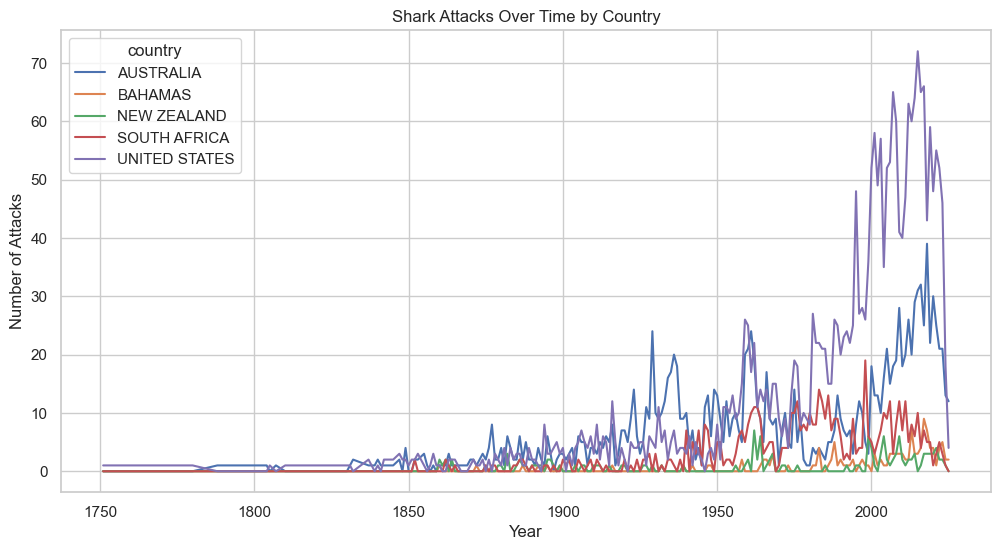

In [58]:
# Compare shark attack trends across countries over time

# Keep top countries
top_countries = (
    df_time[df_time['country'] != 'other']['country']
    .value_counts()
    .head(5)
    .index
)

df_country = df_time[
    df_time['country'].isin(top_countries)
]

# Create country trend table
country_trend = pd.crosstab(
    df_country['year'],
    df_country['country']
)

# Plot trends
country_trend.plot(
    figsize=(12, 6)
)

# Customize labels and title
plt.title("Shark Attacks Over Time by Country")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")

# Display figure
plt.show()

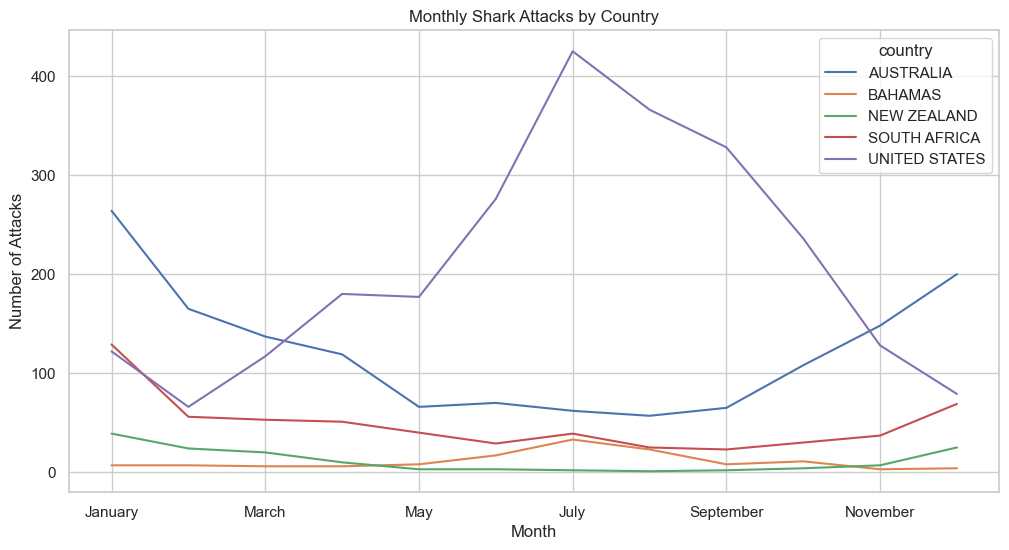

In [60]:
df_time = df3.dropna(subset=['date', 'country']).copy()

df_time['month'] = df_time['date'].dt.month_name()

top_countries = (
    df_time[df_time['country'] != 'other']['country']
    .value_counts()
    .head(5)
    .index
)

df_time = df_time[df_time['country'].isin(top_countries)]

country_month = pd.crosstab(
    df_time['month'],
    df_time['country']
)

month_order = [
    'January', 'February', 'March',
    'April', 'May', 'June',
    'July', 'August', 'September',
    'October', 'November', 'December'
]

country_month = country_month.reindex(month_order)

country_month.plot(figsize=(12,6))

plt.title("Monthly Shark Attacks by Country")
plt.xlabel("Month")
plt.ylabel("Number of Attacks")

plt.show()


In [61]:
country_month

country,AUSTRALIA,BAHAMAS,NEW ZEALAND,SOUTH AFRICA,UNITED STATES
month,,,,,
January,264,7,39,129,122
February,165,7,24,56,66
March,137,6,20,53,117
April,119,6,10,51,180
May,66,8,3,40,177
June,70,17,3,29,276
July,62,33,2,39,425
August,57,23,1,25,366
September,65,8,2,23,328
